<h1><b> Automatidata NYC TLC Taxi Fare Estimation Project </b></h1>

<h3>Capstone Project: Google Advanced Data Analytics Professional Certificate</h3>

<h2><b> Background and Business Problem</b></h2>
<p>
The New York City Taxi and Limousine Commission (TLC) oversees the licensing and regulation of NYC's extensive taxi and for-hire vehicle network, managing over 200,000 licensees who collectively complete approximately one million trips daily. Currently, passengers and drivers lack accurate fare estimation capabilities before rides begin, creating several operational challenges:

- **Passenger uncertainty**: Riders cannot reliably estimate trip costs in advance, leading to customer dissatisfaction and potential disputes
- **Operational inefficiency**: Lack of predictable fare estimates affects trip planning and resource allocation
- **Revenue optimization gaps**: TLC and taxi operators miss opportunities to optimize pricing strategies based on trip characteristics
- **Regulatory oversight limitations**: Without predictive models, TLC cannot effectively analyze fare patterns for policy decisions

To address these challenges, TLC has partnered with Automatidata to develop a robust regression model that accurately estimates taxi fares before rides commence, using historical trip data and relevant variables.</p>

<h2><b>Business Impact</b></h2>
<p>Implementing a predictive fare estimation model will deliver significant measurable business value:
<ul>
    <li><b>Enhanced customer experience:</b> Passengers will receive accurate fare estimates upfront, reducing uncertainty and improving satisfaction</li>
    <li><b>Operational efficiency:</b> Drivers and dispatch systems can optimize route planning and trip acceptance based on estimated fares </li>
    <li><b>Revenue optimization:</b> TLC and taxi operators can implement data-driven pricing strategies to maximize revenue while maintaining competitiveness</li>
    <li><b>Regulatory insights:</b> TLC gains powerful analytical capabilities to monitor fare patterns, detect anomalies, and inform policy decisions</li>
    <li><b>Market competitiveness:</b> Improved fare transparency helps traditional taxis compete more effectively with ride-sharing platforms</li>
</ul>

<h2><b>Methodology</b></h2>
<h4>1) Data Collection and Preparation </h4>
<ul>
    <li> <b>Goal</b>: Construct comprehensive dataframes in Python, perform initial inspection of TLC's historical trip dataset, and communicate findings to stakeholders trip dataset, and communicate findings to stakeholders</li>
<li><b>Understanding the situation:</b> How can the extensive TLC trip data (from 200,000+ licensees) be effectively organized and prepared for analysis? First we start by exploring the dataset. We will try to understand each variable within the dataset and their impact. To understand a bit more about the variable we can read fact sheet provided by company. 
 </li>
 <li><b>Understand the data: </b>Create necessary dataframes to comprehend data structure, quality, and patterns for future exploratory data analysis (EDA) and statistical modeling</li>
 <li><b>Understanding variables: </b>Leverage insights from summary statistics and data examination to guide deeper investigation into key fare-determining variables</li>
    
</ul>


In [77]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 
import plotly.express as px 

df = pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv")
df.head()


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [78]:
df.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

<b> Key observations from above: </b>
- There are 22699 rows and 17 columns.
- There are no null values in any of the columns.
- <b>tpep_pickup_datetime</b> and <b>tpep_dropoff_datetime</b> columns are not in datetime format.


In [80]:
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


<b>Key obseravations from above: </b>
- The <b>trip distance</b> for most rides is between 1 to 3 miles with the largest trip being over 33 miles. Trips with 0 miles need to be analyzed further.
- The maximum <b>fare amount</b> is much higher than the 25-75 percent range of values. It is also odd that the minimum fare amount is a negative value. We will have to look at the distribution of the fare amount.
- Similar observations can be observed with <b>total_amount</b> column.
- The <b>passenger count</b> being 0 in some situation needs further analysis.
- Payment type is categorical data and hence datatype need to be changed accordingly.

In [81]:
# sorting data by trip distance from longest trip to shortest trip 
df_sort = df.sort_values(by=['trip_distance'], ascending=False)
df_sort.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
9280,51810714,2,06/18/2017 11:33:25 PM,06/19/2017 12:12:38 AM,2,33.96,5,N,132,265,2,150.00,0.0,0.0,0.00,0.00,0.3,150.30
13861,40523668,2,05/19/2017 8:20:21 AM,05/19/2017 9:20:30 AM,1,33.92,5,N,229,265,1,200.01,0.0,0.5,51.64,5.76,0.3,258.21
6064,49894023,2,06/13/2017 12:30:22 PM,06/13/2017 1:37:51 PM,1,32.72,3,N,138,1,1,107.00,0.0,0.0,55.50,16.26,0.3,179.06
10291,76319330,2,09/11/2017 11:41:04 AM,09/11/2017 12:18:58 PM,1,31.95,4,N,138,265,2,131.00,0.0,0.5,0.00,0.00,0.3,131.80
29,94052446,2,11/06/2017 8:30:50 PM,11/07/2017 12:00:00 AM,1,30.83,1,N,132,23,1,80.00,0.5,0.5,18.56,11.52,0.3,111.38
18130,90375786,1,10/26/2017 2:45:01 PM,10/26/2017 4:12:49 PM,1,30.50,1,N,132,220,1,90.50,0.0,0.5,19.85,8.16,0.3,119.31
5792,68023798,2,08/11/2017 2:14:01 PM,08/11/2017 3:17:31 PM,1,30.33,2,N,132,158,1,52.00,0.0,0.5,14.64,5.76,0.3,73.20
15350,77309977,2,09/14/2017 1:44:44 PM,09/14/2017 2:34:29 PM,1,28.23,2,N,13,132,1,52.00,0.0,0.5,4.40,5.76,0.3,62.96
10302,43431843,1,05/15/2017 8:11:34 AM,05/15/2017 9:03:16 AM,1,28.20,2,N,90,132,1,52.00,0.0,0.5,11.71,5.76,0.3,70.27
2592,51094874,2,06/16/2017 6:51:20 PM,06/16/2017 7:41:42 PM,1,27.97,2,N,261,132,2,52.00,4.5,0.5,0.00,5.76,0.3,63.06


In [82]:
# sorting amount by total amoutn from high to low
total_amount_sorted = df.sort_values(by=['total_amount'], ascending=False)['total_amount']
total_amount_sorted.head(20)

8476     1200.29
20312     450.30
13861     258.21
12511     233.74
15474     211.80
6064      179.06
16379     157.06
3582      152.30
11269     151.82
9280      150.30
1928      137.80
10291     131.80
6708      126.00
11608     123.30
908       121.56
7281      120.96
18130     119.31
13621     115.94
13359     111.95
29        111.38
Name: total_amount, dtype: float64

In [83]:
total_amount_sorted.tail(20)

14283      0.31
19067      0.30
10506      0.00
5722       0.00
4402       0.00
22566      0.00
1646      -3.30
18565     -3.80
314       -3.80
5758      -3.80
5448      -4.30
4423      -4.30
10281     -4.30
8204      -4.80
20317     -4.80
11204     -5.30
14714     -5.30
17602     -5.80
20698     -5.80
12944   -120.30
Name: total_amount, dtype: float64

In [84]:
# understanding payment types
df.payment_type.value_counts()

1    15265
2     7267
3      121
4       46
Name: payment_type, dtype: int64

In [85]:
# understanding  how much average tip is paid by cash and card 

avg_card_tip = df[df.payment_type==1]['tip_amount'].mean()
print(f'The average card tip is: {avg_card_tip}')

avg_cash_tip = df[df.payment_type==2]['tip_amount'].mean()
print(f'The average cash tip is: {avg_cash_tip}')

The average card tip is: 2.7298001965280054
The average cash tip is: 0.0


In [86]:
# how many times has a vendor driven
df.VendorID.value_counts()

2    12626
1    10073
Name: VendorID, dtype: int64

In [87]:
# mean total amount gained by each vendor 
df.groupby(['VendorID']).agg({'mean'}, numeric_only=True)['total_amount']

C:\Users\RhuthK\AppData\Local\Temp\ipykernel_39364\3355944122.py:2: FutureWarning: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  df.groupby(['VendorID']).agg({'mean'}, numeric_only=True)['total_amount']


,mean
VendorID,
1,16.298119
2,16.320382


In [88]:
# filtering data wehre payments are done by card  
card_payment = df[df.payment_type==1]

# filtering the passenger count for credit card payments
card_payment['passenger_count'].value_counts()

1    10977
2     2168
5      775
3      600
6      451
4      267
0       27
Name: passenger_count, dtype: int64

Key observations:
- There are 27 instances wehre the passenger count was 0.

In [89]:
# how much avg tip was paid for card payment trips based on passenger count 
card_payment.groupby(['passenger_count']).mean()[['tip_amount']]

C:\Users\RhuthK\AppData\Local\Temp\ipykernel_39364\1799231843.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  card_payment.groupby(['passenger_count']).mean()[['tip_amount']]


,tip_amount
passenger_count,
0,2.610370
1,2.714681
2,2.829949
3,2.726800
4,2.607753
5,2.762645
6,2.643326


<h4>2) EDA (Exploratory Data Analysis)  </h4>
<ul>
    <li> <b>Goal</b>: Clean data set and create visualization</li>
<li><b>Understanding the situation:</b> From previous steps we have some basic understanding of the data, important variables, abnormal values in descriptive statistics that require further analysis and variables that might have outliers that need to  be handled.
 </li>
 <li><b>Understand the data: </b>Perform EDA on important columns. Find outliers and handle outliers. Some necessary visualizations to show to stakeholders and creation of dashboard to help non technical stakeholders undestand data with accessibility in mind. </li>
 <li><b>Understanding variables: </b>Leverage insights from previous summary statistics and data examination to guide deeper investigation into key fare-determining variables</li>
    
</ul>

In [90]:
# from previous steps : tpep_pickup_datetime and tpep_dropoff_datetime columns are not in datetime format.abs

# changing to datetime 
df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

<b>Trip distance</b>

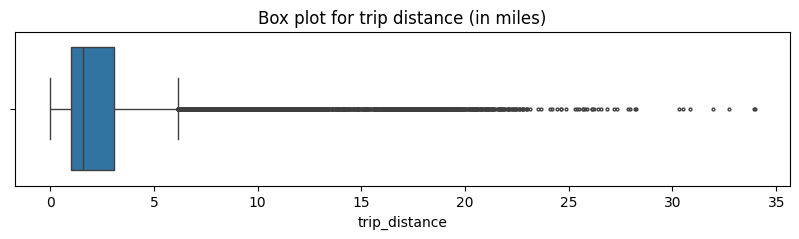

In [92]:
# box plot for trip distance
plt.figure(figsize=(10,2))
sns.boxplot(data=df, x='trip_distance', fliersize=2)
plt.title('Box plot for trip distance (in miles)')
plt.show()

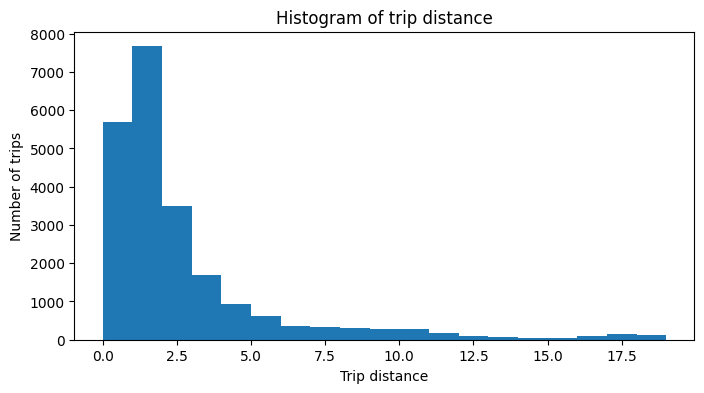

In [94]:
plt.figure(figsize=(8,4))
plt.hist(df.trip_distance, bins=range(0,20,1))
plt.xlabel('Trip distance')
plt.ylabel('Number of trips')
plt.title('Histogram of trip distance')
plt.show()

<b>From the boxplot: </b> we can see that there are many outliers where the trips that are over 6 miles. The data is also skewed to the right with median trip distance being 2 miles. 

<b>From the histogram: </b> The observations from the boxplot can be confirmed through the histogram. Majority of trips were the journey of 2 miles. The number of trips fall steeply as the distance increase beyond 2 miles. 

<b>Total amount</b>

In [99]:
df[['total_amount']].head()

,total_amount
0,16.56
1,20.80
2,8.75
3,27.69
4,17.80


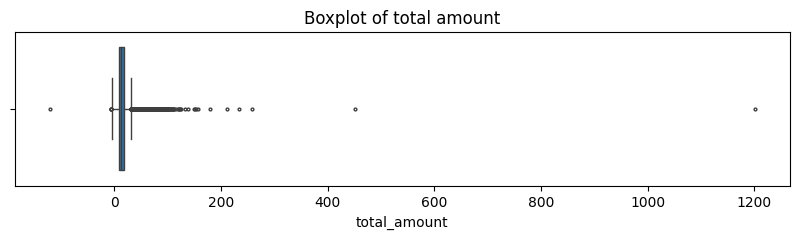

In [115]:
# Box plot for total amount
plt.figure(figsize=(10,2))
plt.title('Boxplot of total amount')
sns.boxplot(data=df, x='total_amount',fliersize=2)
plt.show()

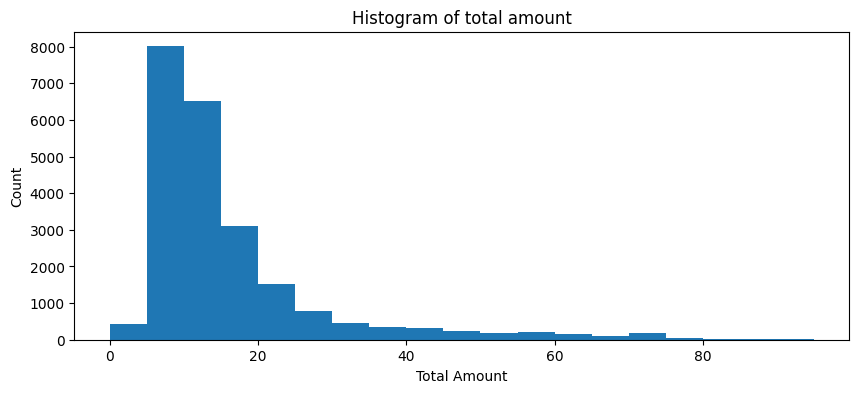

In [129]:
# Histogram for total_amount 
plt.figure(figsize=(10,4))
plt.hist(x=df.total_amount, bins=range(0,100,5))
plt.title('Histogram of total amount')
plt.xlabel("Total Amount")
plt.ylabel('Count')
plt.show()

<b>From the boxplot: </b> The box plot shows that the data contains many outliers while the trips range from 0 to 20 dollars. It looks like there are instances where where the total amount for the trip was negative. 

<b>From the histogram: </b> The histogram shows that the total amount data is highly skewed to the right and most trip costs fell betweem 5 to 15 dollars. 

In [117]:
# finding the instance of negative total amounts
neg_total_amount = df[df.total_amount < 0]
neg_total_amount

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
314,105454287,2,2017-12-13 02:02:39,2017-12-13 02:03:08,6,0.12,1,N,161,161,3,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
1646,57337183,2,2017-07-05 11:02:23,2017-07-05 11:03:00,1,0.04,1,N,79,79,3,-2.5,0.0,-0.5,0.0,0.0,-0.3,-3.3
4423,97329905,2,2017-11-16 20:13:30,2017-11-16 20:14:50,2,0.06,1,N,237,237,4,-3.0,-0.5,-0.5,0.0,0.0,-0.3,-4.3
5448,28459983,2,2017-04-06 12:50:26,2017-04-06 12:52:39,1,0.25,1,N,90,68,3,-3.5,0.0,-0.5,0.0,0.0,-0.3,-4.3
5758,833948,2,2017-01-03 20:15:23,2017-01-03 20:15:39,1,0.02,1,N,170,170,3,-2.5,-0.5,-0.5,0.0,0.0,-0.3,-3.8
8204,91187947,2,2017-10-28 20:39:36,2017-10-28 20:41:59,1,0.41,1,N,236,237,3,-3.5,-0.5,-0.5,0.0,0.0,-0.3,-4.8
10281,55302347,2,2017-06-05 17:34:25,2017-06-05 17:36:29,2,0.00,1,N,238,238,4,-2.5,-1.0,-0.5,0.0,0.0,-0.3,-4.3
11204,58395501,2,2017-07-09 07:20:59,2017-07-09 07:23:50,1,0.64,1,N,50,48,3,-4.5,0.0,-0.5,0.0,0.0,-0.3,-5.3
12944,29059760,2,2017-04-08 00:00:16,2017-04-08 23:15:57,1,0.17,5,N,138,138,4,-120.0,0.0,0.0,0.0,0.0,-0.3,-120.3
14714,109276092,2,2017-12-24 22:37:58,2017-12-24 22:41:08,5,0.40,1,N,164,161,4,-4.0,-0.5,-0.5,0.0,0.0,-0.3,-5.3


In [118]:
neg_total_amount.trip_distance.mean()

0.2578571428571429

It looks like most trips where we have instances of negative total amount happened with Vendor 2 where the trip distance was 0.25 miles on average. As these are the outliers in the data, these instances could be system errors and need to be investigated further. 


<b>tip_amount</b>

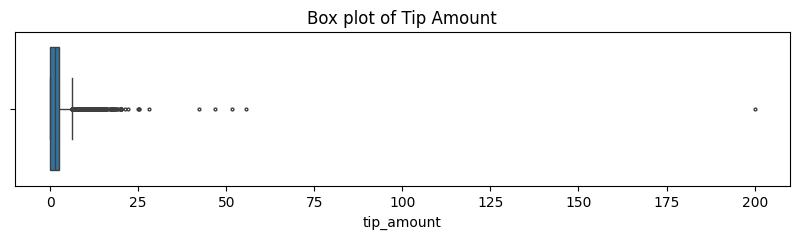

In [122]:
# boxplot for tip amount
plt.figure(figsize=(10,2))
plt.title('Box plot of Tip Amount')
sns.boxplot(data=df, x='tip_amount', fliersize=2)
plt.show()

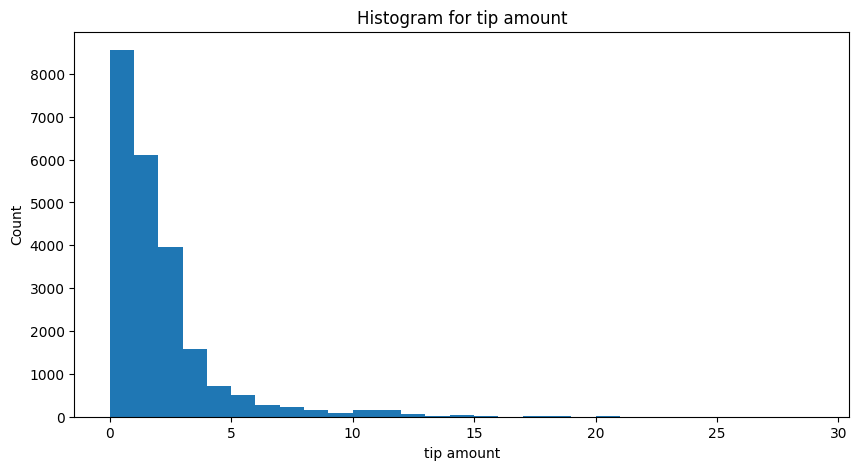

In [130]:
# histogram for tip amount 

plt.figure(figsize=(10,5))
plt.title('Histogram for tip amount')
plt.hist(x=df.tip_amount, bins=range(0,30, 1))
plt.xlabel('tip amount')
plt.ylabel('Count')
plt.show()

<b>From the boxplot: </b> The box plot shows that there are many outliers in the tip amount columns that need to be addressed. 

<b>From the histogram: </b> The histogram shows that majority of tips ranged between 0 and 3 dollars. The data is highly right skewed. 

<b>Tip amount by vendor</b>

AttributeError: Rectangle.set() got an unexpected keyword argument 'multiple'

<Figure size 1000x500 with 0 Axes>

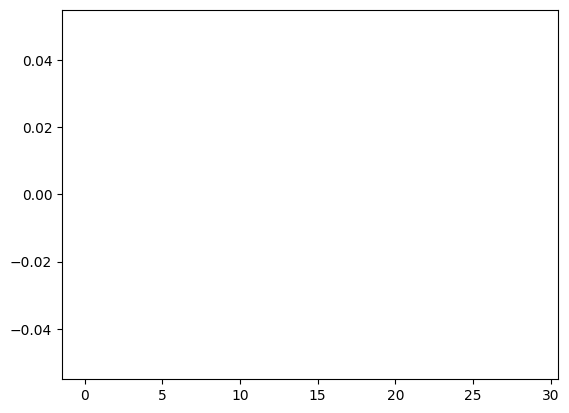

In [133]:
plt.figure(figsize=(10,5))
ax=df.plot(kind='hist',       
       x='tip_amount',
       bins=range(0,30,1),
       multiple='stack')

plt.title('Histogram of Tip amount by Vendor')
plt.show()